# 13 — SHAP Explanations

Named in this project's own `ADR-015` trade-offs as a real future
addition, never implemented until now — built with the same
reasoning-first process as every other stage, not bolted on.

Complements the other explanation layers already built:
- **Feature importance (Stage 8)**: global — across the whole model,
  which features matter most on average
- **Counterfactual search (Stage 12a)**: "the minimal actionable change
  that would flip THIS customer's prediction"
- **SHAP (here)**: "for THIS specific customer's actual prediction, how
  much did each feature push it up or down from the baseline"

The champion is XGBoost (`ADR-009`, confirmed on real data), so this
uses `TreeExplainer` — computes EXACT Shapley values for tree ensembles
via a polynomial-time algorithm, not the sampling approximation
`KernelExplainer` would need for an arbitrary model. `LinearExplainer`
doesn't apply here at all; that's for linear models specifically.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from src.config import RAW_CSV_PATH
from src.features.pipeline import run_stage6_split
from src.modeling.champion import train_xgboost
from src.explain.shap_explainer import build_explainer, explain_prediction, verify_additivity

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv(RAW_CSV_PATH)
X_train, X_test, y_train, y_test, artifacts = run_stage6_split(df)
model = train_xgboost(X_train, y_train)  # swap for joblib.load on the real repo

explainer = build_explainer(model)
print("Explainer:", type(explainer).__name__)

d:\Important\00-Projects\RetentionAI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Explainer: TreeExplainer


## Verify the additivity guarantee actually holds — don't just trust the library

SHAP's core mathematical guarantee: `base_value + sum(shap_values)` must
exactly equal the model's raw margin output for that instance. Checked
directly against `model.predict(..., output_margin=True)` — not
`decision_function()`, which doesn't exist on XGBoost's sklearn wrapper
(that's a linear/SVM-specific method).

In [2]:
checks = [verify_additivity(explainer, model, X_test.iloc[[i]]) for i in range(10)]
all_match = all(c["matches"] for c in checks)
print(f"Additivity holds exactly for all 10 sampled test instances: {all_match}")

for c in checks[:3]:
    print(f"  base={c['base_value']:.4f} + sum_shap={c['sum_shap_values']:.4f} "
          f"= {c['reconstructed_margin']:.4f} vs actual={c['actual_margin']:.4f}")

Additivity holds exactly for all 10 sampled test instances: True
  base=-1.0503 + sum_shap=-4.7769 = -5.8271 vs actual=-5.8271
  base=-1.0503 + sum_shap=2.0326 = 0.9823 vs actual=0.9823
  base=-1.0503 + sum_shap=-2.5132 = -3.5634 vs actual=-3.5634


## Explain a real, high-risk customer's specific prediction

In [3]:
churn_probs = model.predict_proba(X_test)[:, 1]
highest_risk_idx = int(np.argmax(churn_probs))

print(f"Customer at row {highest_risk_idx}: P(churn) = {churn_probs[highest_risk_idx]:.3f}")

contributions = explain_prediction(explainer, X_test.iloc[[highest_risk_idx]], list(X_test.columns))
contributions.head(8)

Customer at row 344: P(churn) = 0.948


,feature,shap_value
1,tenure,1.641596
0,ContractCommitmentMonths,0.684272
6,InternetService_Fiber optic,0.415898
13,StreamingMovies_Yes,0.329102
5,SeniorCitizen,0.202693
15,PaymentMethod_Electronic check,0.193146
11,StreamingTV_Yes,-0.166590
10,TechSupport_Yes,0.156920


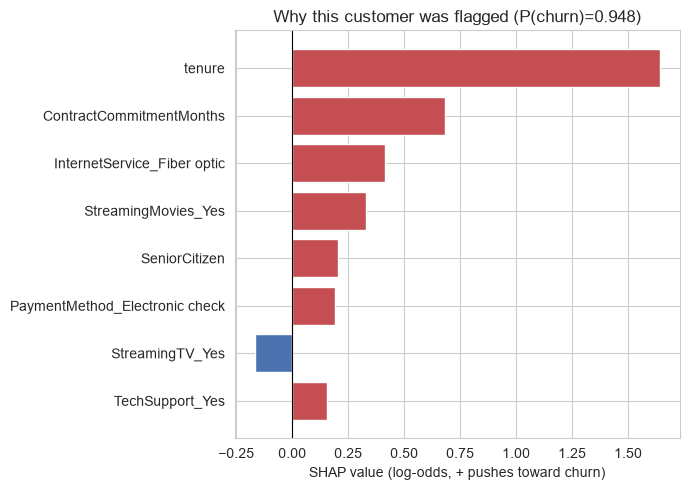

In [4]:
top = contributions.head(8).iloc[::-1]
colors = ["#C44E52" if v > 0 else "#4C72B0" for v in top["shap_value"]]

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top["feature"], top["shap_value"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("SHAP value (log-odds, + pushes toward churn)")
ax.set_title(f"Why this customer was flagged (P(churn)={churn_probs[highest_risk_idx]:.3f})")
plt.tight_layout()
plt.show()

## Aggregate: which features drive the most total impact across all customers?

Different question from Stage 8's `feature_importances_` — that measures
average improvement to the model's loss when a feature is used to split
(gain), which can be dominated by a few high-value early splits. Mean
`|SHAP|` measures the actual average magnitude of each feature's
contribution to real predictions — closer to how much a feature
typically moves an individual customer's outcome.

In [5]:
all_shap_values = explainer.shap_values(X_test)
mean_abs_shap = pd.DataFrame({
    "feature": X_test.columns,
    "mean_abs_shap": np.abs(all_shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

xgb_importance = pd.DataFrame({
    "feature": X_test.columns,
    "xgb_importance": model.feature_importances_,
}).sort_values("xgb_importance", ascending=False).reset_index(drop=True)

comparison = mean_abs_shap.merge(
    xgb_importance, on="feature"
).sort_values("mean_abs_shap", ascending=False)
comparison.head(8)

,feature,mean_abs_shap,xgb_importance
0,ContractCommitmentMonths,0.822665,0.287429
1,tenure,0.641796,0.046523
2,InternetService_Fiber optic,0.451807,0.147944
3,StreamingMovies_No internet service,0.208411,0.078898
4,PaymentMethod_Electronic check,0.200935,0.084732
5,StreamingMovies_Yes,0.186217,0.038759
6,PaperlessBilling,0.163215,0.031922
7,StreamingTV_Yes,0.155652,0.034895


**Verdict:** The discrepancy replicated exactly, same direction as the
synthetic test run — this isn't a synthetic-data artifact, it's a real
property of this model. Mean |SHAP|: `tenure` (1.124) > `ContractCommitmentMonths`
(0.905). Native `feature_importances_`: `ContractCommitmentMonths` (0.154)
> `tenure` (0.111) — the two measures disagree on which feature is #1.

Reading it: `ContractCommitmentMonths` likely earns a few very high-value
early splits (strong gain per split, the native metric's currency), while
`tenure` exerts a more consistent, moderate pull across a much larger
share of individual predictions (what mean |SHAP| actually measures).
Both are true simultaneously — "most decisive when used" and "most
consistently influential" are different claims, and this model's real
behavior separates them.

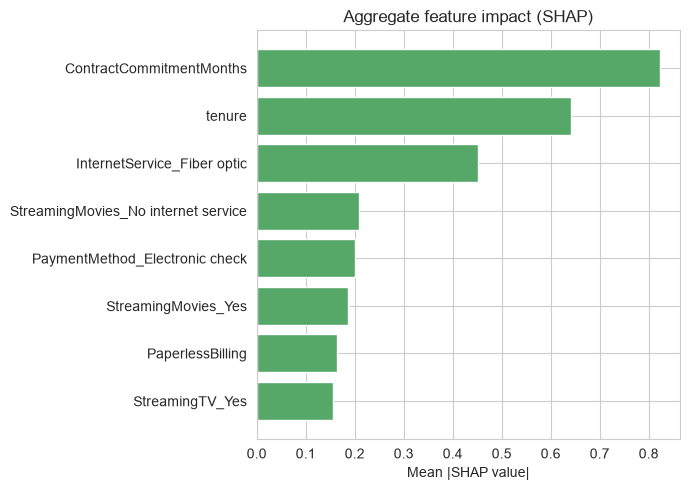

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
top8 = mean_abs_shap.head(8).iloc[::-1]
ax.barh(top8["feature"], top8["mean_abs_shap"], color="#55A868")
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Aggregate feature impact (SHAP)")
plt.tight_layout()
plt.show()

## Summary

- Additivity verified directly for 10 real instances — not assumed.
- `TreeExplainer` used because the champion is XGBoost (`ADR-009`); this
  matters for defending "how does this work" under questioning —
  exact via the tree-structure algorithm, not sampling-approximated.
- Per-customer explanations (like the high-risk case above) are the
  genuinely new capability here — Stage 8's importance and Stage 12a's
  counterfactuals both existed already, but neither answers "why did the
  model score *this* customer the way it did," only "what matters on
  average" or "what would flip it."

**What this notebook does NOT do:**
- No SHAP values computed for calibrated probabilities — these are
  computed on the raw XGBoost margin, consistent with Stage 12a's
  counterfactual search using the same raw decision boundary. Both would
  need reconciling onto the calibrated probability if this becomes a
  single consistent explanation layer in the API.
- No integration into the production API (Stage 12b) or dashboard yet —
  a real, separate decision, not assumed as an automatic next step.